In [ ]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

import maps_core
import context
import alpha_prime

# Reload after editing .py files (one module at a time; dependency order)
importlib.reload(maps_core)
importlib.reload(context)
importlib.reload(alpha_prime)

from context import init_context
from alpha_prime import omega_alpha, dvalpha_dz, dvalpham_dz, G, dlogX_da
from alpha_prime import dthetam, thetam, thetam_inv
from maps_core import real, imag, pi, log, sin, exp, prod, conj
from maps_core import is_inside_domain, diff

import os
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ.get("PATH", "")




In [2]:
# Domain / Schottky parameters (owned by this notebook)
qv = np.array([0.2, 0.2,0.1])
dv = np.array([0.5 - 0.2j, -0.5 + 0.1j,0.5j])
#qv = np.array([0.2,0.5,0.1])

alpha = np.array([[np.pi / 2], [np.pi /2],[0]])
level = 4
dth = pi / 100
ang_p = np.linspace(-pi, pi, 100)
zp = exp(1j * ang_p)

init_context(qv, dv, alpha, level_in=level)


In [3]:
a = -0.4j
b = 0.4 + 0.3j
def G(zeta,a):
    return 1/(2*pi*1j)*log(omega_alpha(zeta,a)/omega_alpha(zeta,1/conj(a))/abs(a))
def Gm(zeta,a,m):
    return 1/(2*pi*1j)*log(omega_alpha(zeta,a)/omega_alpha(zeta,thetam(1/conj(a),m)))
def map1(zeta):
    return omega_alpha(zeta,a)/omega_alpha(zeta,1/conj(a))/abs(a)
def map2(zeta):
    return omega_alpha(zeta,a) * omega_alpha(zeta,1/conj(b))/omega_alpha(zeta,1/conj(a))/omega_alpha(zeta,b)
def map3(zeta):
    return exp(2*pi*1j*(G(zeta,a) - (Gm(zeta,a,2) - 1j*imag(Gm(1,a,2)))))
def Ka(zeta,a):
    return a*dlogX_da(zeta,a)/2
def map4(zeta):
    phi0 = -1/a*Ka(zeta,a) +1/conj(a)*Ka(zeta,1/conj(a))
    return phi0


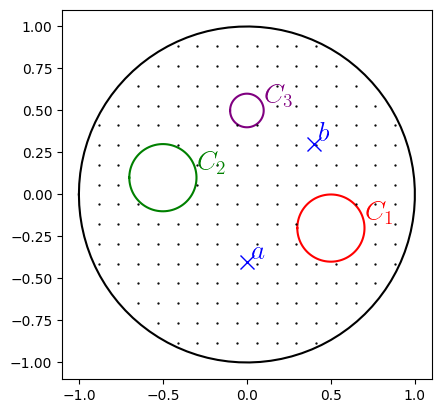

In [ ]:
#a = -0.4j

[X, Y] = np.meshgrid(np.linspace(-1, 1, 18), np.linspace(-1, 1, 18))

plt.figure()
plt.plot(real(zp),imag(zp),'k-')
plt.plot(real(zp*qv[0]+dv[0]),imag(zp*qv[0]+dv[0]),'r-')
plt.plot(real(zp*qv[1]+dv[1]),imag(zp*qv[1]+dv[1]),'g-')
plt.plot(real(zp*qv[2]+dv[2]),imag(zp*qv[2]+dv[2]),color='purple')
plt.axis('equal')
for j in range(len(X)):
    for k in range(len(Y)):
        xx = X[j,k]
        yy = Y[j,k]
        if xx**2 + yy**2 < 1:
            if (xx - real(dv[0]))**2 + (yy - imag(dv[0]))**2 > qv[0]**2:
                if (xx - real(dv[1]))**2 + (yy - imag(dv[1]))**2 > qv[1]**2:
                    if (xx - real(dv[2]))**2 + (yy - imag(dv[2]))**2 > qv[2]**2:
                        plt.plot(xx,yy,'k.',markersize=1.3)
plt.xlim([-1.1,1.1]) 
plt.ylim([-1.1,1.1])  
plt.gca().set_aspect('equal', adjustable='box')
plt.plot(real(a),imag(a),"bx",markersize=10)
plt.plot(real(b),imag(b),"bx",markersize=10)
plt.text(real(dv[0]+qv[0])+0.01, imag(dv[0]+qv[0])+0.05, '$C_1$', color='r', fontsize=20, usetex=True)
plt.text(real(dv[1]+qv[1])+0.01, imag(dv[1]+qv[1])+0.05, '$C_2$', color='g', fontsize=20, usetex=True)
plt.text(real(dv[2]+qv[2])+0.01, imag(dv[2]+qv[2])+0.05, '$C_3$', color='purple', fontsize=20, usetex=True)
plt.text(real(a)+0.03, imag(a)+0.02, r'$a$', color='b', fontsize=20, usetex=True)
plt.text(real(b)+0.03, imag(b)+0.02, r'$b$', color='b', fontsize=20, usetex=True)
#plt.savefig("map1.png")
#plt.savefig("output/figure.pdf")
plt.show()





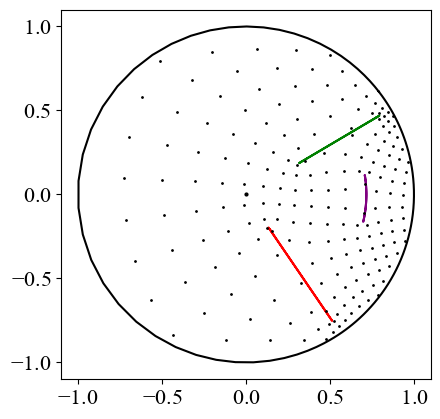

In [ ]:
rc = 1
plt.figure()
plt.plot(real(map1(zp)),imag(map1(zp)),'k-')
plt.plot(real(map1(zp*qv[0]+dv[0])),imag(map1(zp*qv[0]+dv[0])),'r-')
plt.plot(real(map1(zp*qv[1]+dv[1])),imag(map1(zp*qv[1]+dv[1])),'g-')
plt.plot(real(map1(zp*qv[2]+dv[2])),imag(map1(zp*qv[2]+dv[2])),'-',color='purple')
plt.axis('equal')
for j in range(len(X)):
    for k in range(len(Y)):
        xx = X[j,k]
        yy = Y[j,k]
        if xx**2 + yy**2 < 1:
            if (xx - real(dv[0]))**2 + (yy - imag(dv[0]))**2 > qv[0]**2:
                if (xx - real(dv[1]))**2 + (yy - imag(dv[1]))**2 > qv[1]**2:
                    if (xx - real(dv[2]))**2 + (yy - imag(dv[2]))**2 > qv[2]**2:
                        plt.plot(real(map1(xx+1j*yy)),imag(map1(xx+1j*yy)),'k.',markersize=2)
                        #print("hoge")
plt.plot(0,0,"k.",markersize=4)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
#plt.savefig("output/map1.pdf")
plt.show()


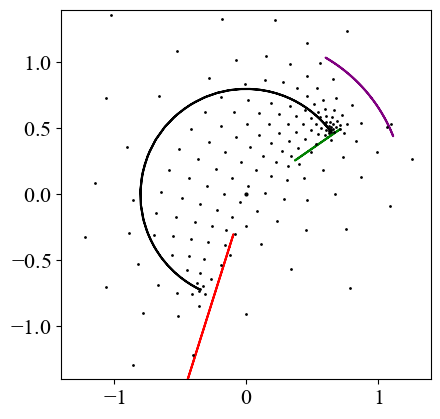

In [ ]:
rc = 1
plt.figure()
plt.plot(real(map2(zp)),imag(map2(zp)),'k-')
plt.plot(real(map2(zp*qv[0]+dv[0])),imag(map2(zp*qv[0]+dv[0])),'r-')
plt.plot(real(map2(zp*qv[1]+dv[1])),imag(map2(zp*qv[1]+dv[1])),'g-')
plt.plot(real(map2(zp*qv[2]+dv[2])),imag(map2(zp*qv[2]+dv[2])),'-',color='purple')
plt.axis('equal')
for j in range(len(X)):
    for k in range(len(Y)):
        xx = X[j,k]
        yy = Y[j,k]
        if xx**2 + yy**2 < 1:
            if (xx - real(dv[0]))**2 + (yy - imag(dv[0]))**2 > qv[0]**2:
                if (xx - real(dv[1]))**2 + (yy - imag(dv[1]))**2 > qv[1]**2:
                    if (xx - real(dv[2]))**2 + (yy - imag(dv[2]))**2 > qv[2]**2:
                        plt.plot(real(map2(xx+1j*yy)),imag(map2(xx+1j*yy)),'k.',markersize=2)
                        #print("hoge")
plt.plot(0,0,"k.",markersize=4)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-1.4, 1.4)
plt.ylim(-1.4, 1.4)
#plt.savefig("output/map2.pdf")
plt.show()


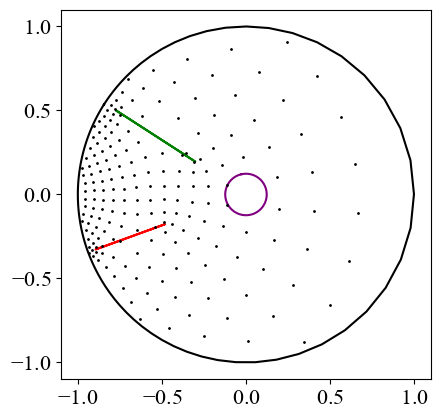

In [ ]:
rc = 1
plt.figure()
plt.plot(real(map3(zp)),imag(map3(zp)),'k-')
plt.plot(real(map3(zp*qv[0]+dv[0])),imag(map3(zp*qv[0]+dv[0])),'r-')
plt.plot(real(map3(zp*qv[1]+dv[1])),imag(map3(zp*qv[1]+dv[1])),'g-')
plt.plot(real(map3(zp*qv[2]+dv[2])),imag(map3(zp*qv[2]+dv[2])),'-',color='purple')
plt.axis('equal')
for j in range(len(X)):
    for k in range(len(Y)):
        xx = X[j,k]
        yy = Y[j,k]
        if xx**2 + yy**2 < 1:
            if (xx - real(dv[0]))**2 + (yy - imag(dv[0]))**2 > qv[0]**2:
                if (xx - real(dv[1]))**2 + (yy - imag(dv[1]))**2 > qv[1]**2:
                    if (xx - real(dv[2]))**2 + (yy - imag(dv[2]))**2 > qv[2]**2:
                        plt.plot(real(map3(xx+1j*yy)),imag(map3(xx+1j*yy)),'k.',markersize=2)
                        #print("hoge")
#plt.plot(0,0,"k.",markersize=4)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
#plt.savefig("output/map3.pdf")
plt.show()


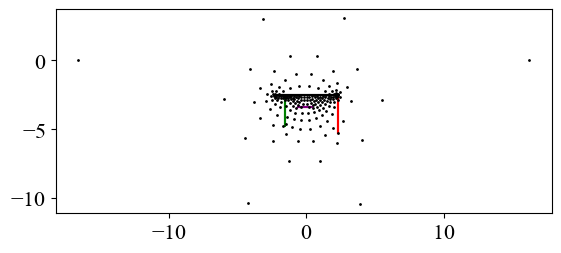

In [ ]:
rc = 1
plt.figure()
plt.plot(real(map4(zp)),imag(map4(zp)),'k-')
plt.plot(real(map4(zp*qv[0]+dv[0])),imag(map4(zp*qv[0]+dv[0])),'r-')
plt.plot(real(map4(zp*qv[1]+dv[1])),imag(map4(zp*qv[1]+dv[1])),'g-')
plt.plot(real(map4(zp*qv[2]+dv[2])),imag(map4(zp*qv[2]+dv[2])),'-',color='purple')
plt.axis('equal')
for j in range(len(X)):
    for k in range(len(Y)):
        xx = X[j,k]
        yy = Y[j,k]
        if xx**2 + yy**2 < 1:
            if (xx - real(dv[0]))**2 + (yy - imag(dv[0]))**2 > qv[0]**2:
                if (xx - real(dv[1]))**2 + (yy - imag(dv[1]))**2 > qv[1]**2:
                    if (xx - real(dv[2]))**2 + (yy - imag(dv[2]))**2 > qv[2]**2:
                        plt.plot(real(map4(xx+1j*yy)),imag(map4(xx+1j*yy)),'k.',markersize=2)
                        #print("hoge")
#plt.plot(0,0,"k.",markersize=4)
plt.gca().set_aspect('equal', adjustable='box')
#plt.xlim(-1.1, 1.1)
#plt.ylim(-1.1, 1.1)
#plt.savefig("output/map4.pdf")
plt.show()
